In [7]:
import os
import pandas as pd
import pprint as pp
import random
import codenet_reader  # functions for reading data from codenet
import transformers

In [8]:
# Functions for processing solutions of a problem
def process_pid(pid: str, data: list[pd.DataFrame], tokenizer, random_state: int = 42):
    MIN_SOLUTIONS = 1000
    NUM_ACCEPTED = 500
    NUM_REJECTED = 500

    num_python_solutions = len(codenet_reader.python_solutions(pid))
    if num_python_solutions < MIN_SOLUTIONS:
        return

    df = codenet_reader.init_metadata_df(pid)
    df = df[df["status"].isin({"Accepted", "Wrong Answer"})]
    
    if df is None:
        return
    
    df["code"] = df.apply(lambda row: codenet_reader.read_solution_file(pid, row["submission_id"]), axis=1)
    
    # Filter solutions that are too short or too long
    if tokenizer:
        df["num_tokens"] = df["code"].apply(lambda x: len(tokenizer.encode(x)))
        df = df[(df["num_tokens"] >= 5) & (df["num_tokens"] < 256)]
    
    if df.shape[0] < MIN_SOLUTIONS:
        return
    
    df_accepted = df[df["status"] == "Accepted"]
    df_rejected = df[df["status"] != "Accepted"]
    hardness = df_rejected.shape[0] / df.shape[0]
    
    if df_accepted.shape[0] < NUM_ACCEPTED:
        return
    if df_rejected.shape[0] < NUM_REJECTED:
        return
    
    print(f"{pid}: Sampling from {df.shape[0]:04d} code snippets.", f"Hardness: {hardness:.4f}")
    # Sample accepted and rejected solutions
    df = pd.concat([
        df_accepted.sample(NUM_ACCEPTED, random_state=random_state),
        df_rejected.sample(NUM_REJECTED, random_state=random_state)
    ], ignore_index=True)
    
    # Aggregate data
    data.append(df)
    return hardness

In [ ]:
def test():
    data = []
    process_pid("p0335", data, None)
    #process_pid('p01701', data)
    df = pd.concat(data, ignore_index=True)
    pp.pp(df)

In [10]:
test()

ValueError: No objects to concatenate

In [11]:
# Reading data
RANDOM_SEED = 42
#SAMPLE_SIZE = 4000  # Sample 4000 problems
random.seed(RANDOM_SEED)

tokenizer = transformers.AutoTokenizer.from_pretrained("microsoft/codebert-base")

_pids = os.listdir(codenet_reader.DATA_PATH)
#_pids = random.sample(_pids, k=min(SAMPLE_SIZE, len(_pids)))

print("Starting...")
print(f"Processing {len(_pids)} problems.")

_pid_hardness = {}
data = []
for _pid in _pids:
    hardness = process_pid(_pid, data, tokenizer, random_state=RANDOM_SEED)
    if hardness is not None: _pid_hardness[_pid] = hardness

print("Data gathered.")

df = pd.concat(data, ignore_index=True)
df = df.drop_duplicates(subset=["submission_id"])
pp.pp(df)

print("DONE")

Token indices sequence length is longer than the specified maximum sequence length for this model (1568 > 512). Running this sequence through the model will result in indexing errors


Starting...
Processing 4053 problems.
p03352: Sampling from 1720 code snippets. Hardness: 0.4703
p02731: Sampling from 4616 code snippets. Hardness: 0.1577
p02707: Sampling from 4782 code snippets. Hardness: 0.1648
p02547: Sampling from 2955 code snippets. Hardness: 0.1963
p02755: Sampling from 7352 code snippets. Hardness: 0.5173
p02754: Sampling from 6750 code snippets. Hardness: 0.3919
p03000: Sampling from 1701 code snippets. Hardness: 0.4039
p03289: Sampling from 1408 code snippets. Hardness: 0.4588
p02582: Sampling from 4629 code snippets. Hardness: 0.2921
p02658: Sampling from 12000 code snippets. Hardness: 0.5613
p02659: Sampling from 22861 code snippets. Hardness: 0.8142
p02812: Sampling from 4185 code snippets. Hardness: 0.1379
p02676: Sampling from 6503 code snippets. Hardness: 0.1901
p02646: Sampling from 5260 code snippets. Hardness: 0.6369
p02953: Sampling from 2083 code snippets. Hardness: 0.4983
p02612: Sampling from 7455 code snippets. Hardness: 0.3344
p02556: Sampling

In [16]:
df_problem_counts = df.groupby("problem_id")["status"].value_counts().unstack(fill_value=0)
df_problem_counts

status,Accepted,Wrong Answer
problem_id,,
p02547,500,500
p02553,500,500
p02554,500,500
p02556,500,500
p02570,500,500
...,...,...
p03723,500,500
p03835,500,500
p03854,500,500


In [13]:
df_problem_hardness = pd.DataFrame.from_dict(_pid_hardness, orient="index", columns=["hardness"])
df_problem_hardness

,hardness
p03352,0.470349
p02731,0.157712
p02707,0.164785
p02547,0.196277
p02755,0.517274
...,...
p02922,0.557643
p02601,0.367185
p03001,0.449024
p02791,0.259656


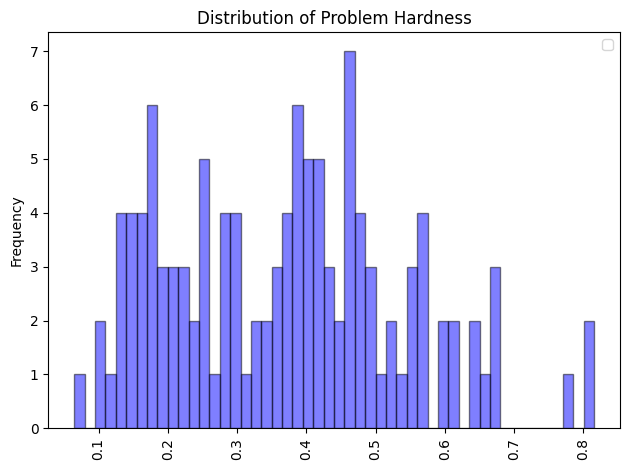

In [14]:
import matplotlib.pyplot as plt

ax = df_problem_hardness.sort_values(by="hardness", ascending=True).plot(
    kind="hist",
    bins=50,
    alpha=0.5,
    color='blue',
    edgecolor='black',
)
ax.legend([])

plt.title("Distribution of Problem Hardness")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
# Exporting
EXPORTED_FILE_NAME = "output_very_big.csv"

df[["problem_id","submission_id","status","code"]].to_csv(path_or_buf=EXPORTED_FILE_NAME, index=False)